# Regularización en Redes Neuronales con TensorFlow

## **L1 (Lasso)**

$$
\min_{\mathbf{w}} \{ \mathcal{L}(\mathbf{w}) + \lambda ||\mathbf{w}||_1 \}
$$

$$
||\mathbf{w}||_1 = \sum_i |w_i|
$$

Penaliza la suma de los valores absolutos de los pesos. Promueve **sparsity**, realiza selección automática de variables y mejora la interpretabilidad del modelo.

---

## **L2 (Ridge)**

$$
\min_{\mathbf{w}} \{ \mathcal{L}(\mathbf{w}) + \lambda ||\mathbf{w}||_2^2 \}
$$

$$
||\mathbf{w}||_2^2 = \sum_i w_i^2
$$

Penaliza la suma de los cuadrados de los pesos. Reduce la varianza, estabiliza el entrenamiento y mitiga los efectos de la colinealidad al distribuir los pesos.

---

## **Elastic Net (L1 + L2)**

$$
\min_{\mathbf{w}} \{ \mathcal{L}(\mathbf{w}) + \lambda_1 ||\mathbf{w}||_1 + \lambda_2 ||\mathbf{w}||_2^2 \}
$$

Combinación de L1 y L2. Mantiene sparsity mientras conserva estabilidad numérica, siendo útil cuando existen variables altamente correlacionadas.

---

## **Dropout**

$$
\min_{\mathbf{w}} \{ \mathbb{E}_{\mathbf{m} \sim \text{Bernoulli}(p)} 
\left[ \mathcal{L}\big(f(x; \mathbf{w}, \mathbf{m})\big) \right] \}
$$

$$
\tilde{h}_i = \frac{m_i}{p} h_i, \quad m_i \sim \text{Bernoulli}(p)
$$

Apaga neuronas aleatoriamente durante el entrenamiento (regularización estocástica estructural), Esto logra que la red no dependa demasiado de ninguna neurona individual.

---


In [1]:
# E[h_hat] = h_i

# E[h_hat] = E[(mi*h_i)/ p] = (h_i / p) * E[mi] = (h_i / p) * p  = hi

# E[x] = mu


In [2]:
import tensorflow as tf
from tensorflow.keras import layers, regularizers

import numpy as np
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt


2026-09-01 11:55:56.599640: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1788285356.617192  773612 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1788285356.622505  773612 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1788285356.635537  773612 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1788285356.635561  773612 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1788285356.635563  773612 computation_placer.cc:177] computation placer alr

## Cargar datos

In [3]:
X, y = make_moons(1000, noise=0.3, random_state=0)

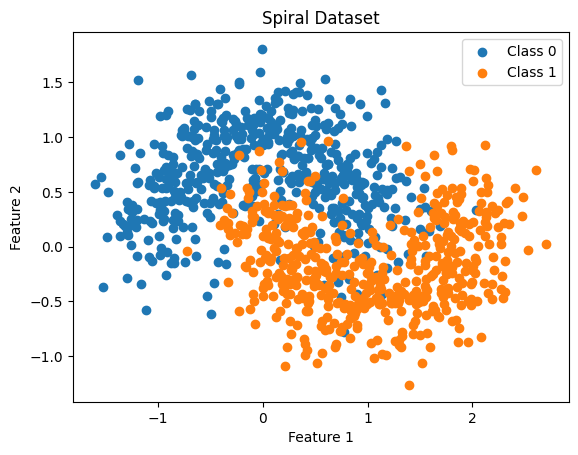

In [4]:
plt.scatter(X[y == 0, 0], X[y == 0, 1], label='Class 0')
plt.scatter(X[y == 1, 0], X[y == 1, 1], label='Class 1')
plt.title('Spiral Dataset')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()

In [5]:
X = np.concatenate([X,X], axis = 1)

In [6]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [7]:
x_train

array([[ 0.67775553,  0.22852976,  0.67775553,  0.22852976],
       [ 0.41635687, -0.58922562,  0.41635687, -0.58922562],
       [ 0.17845946,  0.69243608,  0.17845946,  0.69243608],
       ...,
       [ 0.9935866 ,  0.27959555,  0.9935866 ,  0.27959555],
       [-0.25297352,  1.12168846, -0.25297352,  1.12168846],
       [ 0.17430005,  0.42379021,  0.17430005,  0.42379021]])

## Función para crear modelos

In [8]:
def build_model(reg=None, dropout_rate=None):
    model = tf.keras.Sequential()
    model.add(layers.Input(shape=(4,)))
    model.add(layers.Dense(64, activation='relu'))
    model.add(layers.Dense(64, activation='relu'))

    if reg:
        model = tf.keras.Sequential()
        model.add(layers.Input(shape=(4,)))
        model.add(layers.Dense(64, activation='relu', kernel_regularizer=reg))
        model.add(layers.Dense(64, activation='relu', kernel_regularizer=reg))

    if dropout_rate:
        model = tf.keras.Sequential()
        model.add(layers.Input(shape=(4,)))
        model.add(layers.Dense(64, activation='relu'))
        model.add(layers.Dropout(dropout_rate))
        model.add(layers.Dense(64, activation='relu'))
        model.add(layers.Dropout(dropout_rate))


    model.add(layers.Dense(2, activation='softmax'))

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return model


## Entrenar modelos con distintas regularizaciones

In [9]:
1e-4

0.0001

In [10]:

configs = {
    "Baseline": {},
    "L1": {"reg": regularizers.l1(1e-3)},
    "L2": {"reg": regularizers.l2(1e-3)},
    "ElasticNet": {"reg": regularizers.l1_l2(l1=1e-3, l2=1e-3)},
    "Dropout": {"dropout_rate": 0.2},
}

histories = {}
results = {}

for name, cfg in configs.items():
    print(f"Training {name}")
    model = build_model(**cfg)
    history = model.fit(
        x_train, y_train,
        validation_split=0.1,
        epochs=100,
        batch_size=64,
        verbose=1
    )
    loss, acc = model.evaluate(x_test, y_test, verbose=0)
    histories[name] = history
    results[name] = acc


I0000 00:00:1788285359.865348  773612 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13466 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4070 Ti SUPER, pci bus id: 0000:07:00.0, compute capability: 8.9


Training Baseline
Epoch 1/100


I0000 00:00:1788285361.484469  773760 service.cc:152] XLA service 0x750f8c0097b0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1788285361.484489  773760 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 4070 Ti SUPER, Compute Capability 8.9
2026-09-01 11:56:01.503226: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1788285361.629956  773760 cuda_dnn.cc:529] Loaded cuDNN version 91001
2026-09-01 11:56:02.686106: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_142', 4 bytes spill stores, 4 bytes spill loads



 1/12 ━━━━━━━━━━━━━━━━━━━━ 34s 3s/step - accuracy: 0.2500 - loss: 0.7911

I0000 00:00:1788285364.019512  773760 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
2026-09-01 11:56:04.789511: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_135', 8 bytes spill stores, 8 bytes spill loads



12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 209ms/step - accuracy: 0.5225 - loss: 0.7022 - val_accuracy: 0.8875 - val_loss: 0.5076
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8696 - loss: 0.4808 - val_accuracy: 0.8750 - val_loss: 0.3685
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8774 - loss: 0.3714 - val_accuracy: 0.8875 - val_loss: 0.2908
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8574 - loss: 0.3250 - val_accuracy: 0.8875 - val_loss: 0.2633
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8808 - loss: 0.2875 - val_accuracy: 0.8875 - val_loss: 0.2565
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8782 - loss: 0.2977 - val_accuracy: 0.8875 - val_loss: 0.2552
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8898 - loss: 0.2728 - val_accuracy: 0.8875 - val_loss: 0.2554
Epoch 8/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8867 - loss: 0.2985 - val_accuracy: 0.8875 - val_loss: 0

2026-09-01 11:56:18.192554: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_35', 8 bytes spill stores, 8 bytes spill loads



Training L1
Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 167ms/step - accuracy: 0.6012 - loss: 1.1619 - val_accuracy: 0.8875 - val_loss: 0.9558
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8183 - loss: 0.9415 - val_accuracy: 0.9000 - val_loss: 0.8067
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8394 - loss: 0.8328 - val_accuracy: 0.8875 - val_loss: 0.7187
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8630 - loss: 0.7564 - val_accuracy: 0.8875 - val_loss: 0.6654
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8495 - loss: 0.7105 - val_accuracy: 0.8875 - val_loss: 0.6325
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8491 - loss: 0.7016 - val_accuracy: 0.8875 - val_loss: 0.6054
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8773 - loss: 0.6399 - val_accuracy: 0.8875 - val_loss: 0.5828
Epoch 8/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8770 - loss: 0.6131 - val_accura

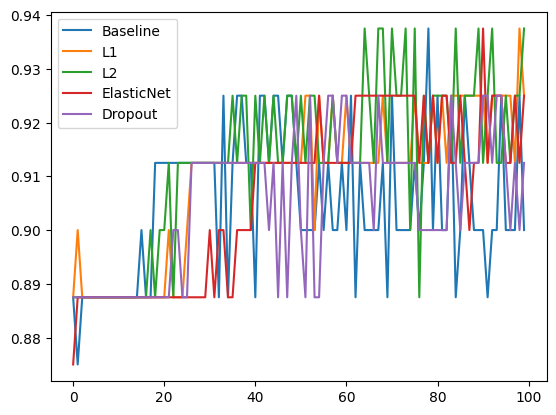

In [11]:
plt.plot(histories["Baseline"].history['val_accuracy'], label='Baseline')
plt.plot(histories["L1"].history['val_accuracy'], label='L1')
plt.plot(histories["L2"].history['val_accuracy'], label='L2')
plt.plot(histories["ElasticNet"].history['val_accuracy'], label='ElasticNet')
plt.plot(histories["Dropout"].history['val_accuracy'], label='Dropout')
plt.legend()
plt.show()

In [17]:
W, b = model.layers[0].get_weights()

## Comparativa de Accuracy

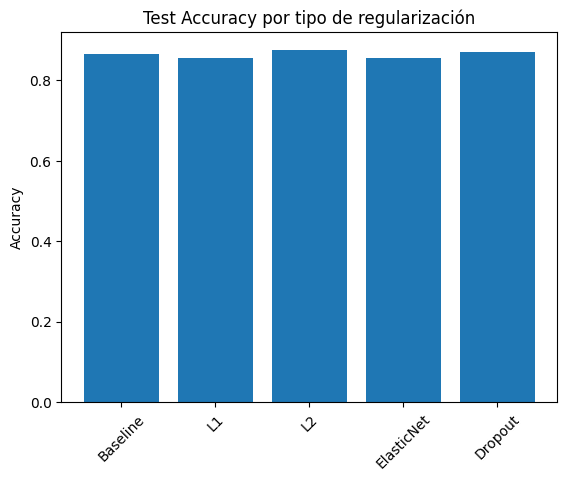

In [12]:

names = list(results.keys())
accs = list(results.values())

plt.figure()
plt.bar(names, accs)
plt.title("Test Accuracy por tipo de regularización")
plt.ylabel("Accuracy")
plt.xticks(rotation=45)
plt.show()


In [13]:
accs

[0.8650000095367432,
 0.8550000190734863,
 0.875,
 0.8550000190734863,
 0.8700000047683716]